In [1]:
import torch
from PIL import Image
from torchvision.transforms.functional import to_pil_image, to_tensor

from dct_autoencoder import DCTAutoencoder

## DCTAutoEncoder


Instantiate a `DCTAutoencoder` object as follow: 

In [2]:
# total channels will be 3 * block_size**2 which is 768 for block size 16
block_size = 16
# keep 96 lowest-frequency luminance channels
num_luminance_compressed_channels = 96  
# keep 16 lowest-frequency chrominance channels
num_chrominance_compressed_channels = (
    16  
)
dct_autoencoder = DCTAutoencoder(
    block_size=block_size,
    num_luminance_compressed_channels=num_luminance_compressed_channels,
    num_chrominance_compressed_channels=num_chrominance_compressed_channels,
)

`dct_autoencoder` is a `torch.nn.Module` and is fully differentiable:

In [3]:
print(f"{isinstance(dct_autoencoder, torch.nn.Module)=}")

isinstance(dct_autoencoder, torch.nn.Module)=True


Open test image:

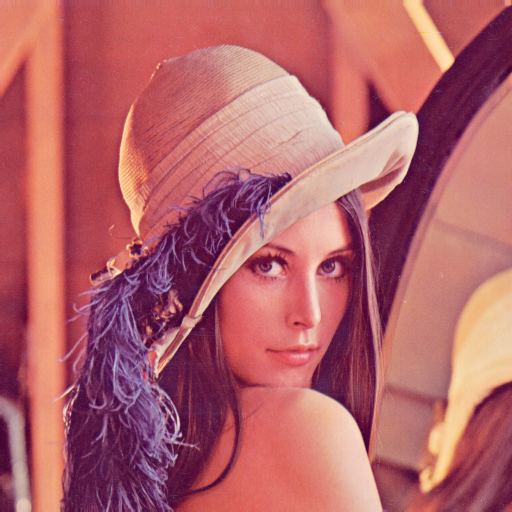

In [4]:
image = Image.open("./test_images/Lenna_(test_image).png")
image

### Encoding


In [5]:
image_tensor = to_tensor(image)
print(f"{image_tensor.shape=}")
batch = image_tensor.unsqueeze(0)
dct_encodings = dct_autoencoder.encode(batch)
print(f"{dct_encodings.shape=}")

image_tensor.shape=torch.Size([3, 512, 512])
dct_encodings.shape=torch.Size([1, 768, 32, 32])


### Decoding


Note: When using decoder in training disable output clamping to avoid zero gradient for satuated pixels:

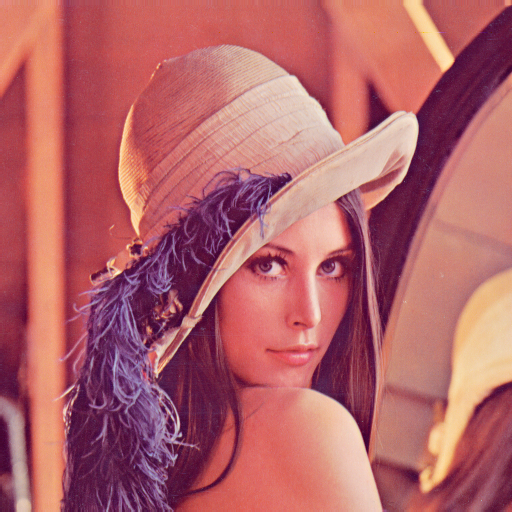

In [6]:
reconstructed_batch = dct_autoencoder.decode(dct_encodings, clamp_output=True)
reconstructed_image = reconstructed_batch.squeeze(0)
torch.testing.assert_close(batch, reconstructed_batch, rtol=1e-3, atol=1e-3)
to_pil_image(reconstructed_image)

### Compress


In [7]:
print(f"{dct_autoencoder.get_num_compressed_channels()=}")

dct_autoencoder.get_num_compressed_channels()=128


In [8]:
compressed_dct_encodings = dct_autoencoder.compress(dct_encodings)
print(f"{compressed_dct_encodings.shape=}")
compression_ratio = dct_encodings.numel() / compressed_dct_encodings.numel()
print(f"{compression_ratio=}")

compressed_dct_encodings.shape=torch.Size([1, 128, 32, 32])
compression_ratio=6.0


## Decompress


decompressed_dct_encodings.shape=torch.Size([1, 768, 32, 32])


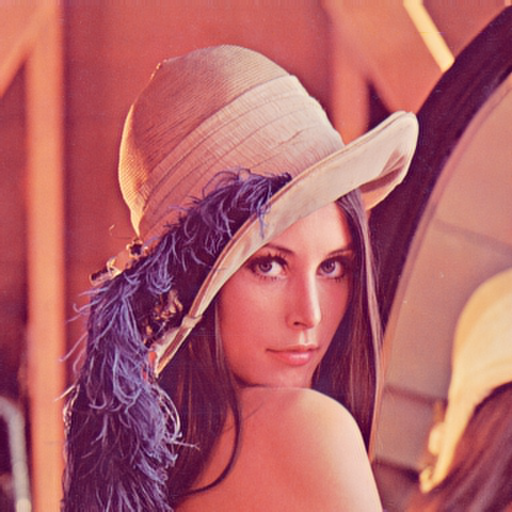

In [9]:
decompressed_dct_encodings = dct_autoencoder.decompress(compressed_dct_encodings)
print(f"{decompressed_dct_encodings.shape=}")
decompressed_batch = dct_autoencoder.decode(decompressed_dct_encodings)
decompressed_image = decompressed_batch.squeeze(0)
to_pil_image(decompressed_image)